In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

# Customer Churn and Retention Analysis 

## Business Question: 
Why are customers leaving the company, which customer segments are most at risk, what retention strategies should 
the company prioritize? 

### Tools: 
- Python
- SQL
- Power BI

#### Data Examinig & Cleaning 

In [2]:
df = pd.read_excel("Telco_customer_churn 2.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df.shape

(7043, 33)

Analyzing each column
- object = text/categorical data
- int64 = whole number
- float64 = decimal number 

In [4]:
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [5]:
# Checking for any missing values 
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [6]:
# Checking for duplicates 

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["CustomerID"].duplicated().sum()

np.int64(0)

In [9]:
# Checking how many customers didn't and did churn 

In [10]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [11]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [12]:
# Inspecting the beginning and end values of the "Total Charges" column

In [13]:
df["Total Charges"].head(10)

0     108.15
1     151.65
2      820.5
3    3046.05
4     5036.3
5     528.35
6      39.65
7      20.15
8    4749.15
9       30.2
Name: Total Charges, dtype: object

In [14]:
df["Total Charges"].tail(10)

7033      39.25
7034     3316.1
7035    2625.25
7036     1495.1
7037      743.3
7038     1419.4
7039     1990.5
7040     7362.9
7041     346.45
7042     6844.5
Name: Total Charges, dtype: object

In [15]:
# Figuring out why those 11 strings were blank: new customers who have not completed a month of service, therefore accumulated total charges equals zero. Treat 11 blank values as zero.

In [16]:
df["Total Charges"].str.strip() == ""

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Name: Total Charges, Length: 7043, dtype: bool

In [17]:
df["Total Charges"].apply(type).value_counts()

Total Charges
<class 'float'>    6708
<class 'int'>       324
<class 'str'>        11
Name: count, dtype: int64

In [18]:
df["Total Charges"].head(20).tolist()

[108.15,
 151.65,
 820.5,
 3046.05,
 5036.3,
 528.35,
 39.65,
 20.15,
 4749.15,
 30.2,
 1093.1,
 316.9,
 3549.25,
 1105.4,
 144.15,
 1426.4,
 633.3,
 1752.55,
 857.25,
 79.35]

In [19]:
df[df["Total Charges"].apply(lambda x: isinstance(x, str))]
[["CustomerID", "Tenure Months", "Monthly Charges", "Total Charges", "Churn Label"]] 

[['CustomerID',
  'Tenure Months',
  'Monthly Charges',
  'Total Charges',
  'Churn Label']]

In [20]:
string_rows = df["Total Charges"].map(type).eq(str)
string_rows.sum()

np.int64(11)

In [21]:
df.loc[string_rows, "Total Charges"].tolist()

[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']

In [22]:
df.loc[string_rows, ["CustomerID", "Tenure Months", "Monthly Charges", "Total Charges", "Churn Label"]]

,CustomerID,Tenure Months,Monthly Charges,Total Charges,Churn Label
2234,4472-LVYGI,0,52.55,,No
2438,3115-CZMZD,0,20.25,,No
2568,5709-LVOEQ,0,80.85,,No
2667,4367-NUYAO,0,25.75,,No
2856,1371-DWPAZ,0,56.05,,No
4331,7644-OMVMY,0,19.85,,No
4687,3213-VVOLG,0,25.35,,No
5104,2520-SGTTA,0,20.00,,No
5719,2923-ARZLG,0,19.70,,No
6772,4075-WKNIU,0,73.35,,No


In [23]:
# Replacing the 11 blank strings with Nan (0) and verfied if it worked. 

In [24]:
df_clean = df.copy()

In [25]:
df_clean["Total Charges"] = pd.to_numeric(df_clean["Total Charges"], errors="coerce")
df_clean["Total Charges"] = df_clean["Total Charges"].fillna(0)

In [26]:
df_clean["Total Charges"].dtype

dtype('float64')

In [27]:
df_clean["Total Charges"].isna().sum()

np.int64(0)

In [28]:
df_clean.shape

(7043, 33)

In [29]:
# Checking some categorical variables for any inconsistencies. 

In [30]:
df_clean["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [31]:
df_clean["Internet Service"].value_counts()

Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [32]:
df_clean["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [33]:
# Looking at all categorical variables and their unique categories
categorical_columns = df_clean.select_dtypes(include="object").columns
for column in categorical_columns:
    print(f"\n{column}:")
    print(df_clean[column].unique())


CustomerID:
['3668-QPYBK' '9237-HQITU' '9305-CDSKC' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK']

Country:
['United States']

State:
['California']

City:
['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley']

Lat Long:
['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401']

Gender:
['Male' 'Female']

Senior Citizen:
['No' 'Yes']

Partner:
['No' 'Yes']

Dependents:
['No' 'Yes']

Phone Service:
['Yes' 'No']

Multiple Lines:
['No' 'Yes' 'No phone service']

Internet Service:
['DSL' 'Fiber optic' 'No']

Online Security:
['Yes' 'No' 'No internet service']

Online Backup:
['Yes' 'No' 'No internet service']

Device Protection:
['No' 'Yes' 'No internet service']

Tech Support:
['No' 'Yes' 'No internet service']

Streaming TV:
['No' 'Yes' 'No internet service']

Streaming Movies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'Two year'

In [34]:
# Creating a new dataframe that includes variables that will be analyzed. 
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Total Charges,7043.0,2279.734304,2266.794470,0.000000,398.550000,1394.550000,3786.600000,8684.800000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [35]:
analysis_columns = ["Gender", "Senior Citizen", "Partner", "Dependents", "Tenure Months", 
                    "Phone Service", "Multiple Lines", "Internet Service", "Online Security",
                    "Online Backup", "Device Protection", "Tech Support", "Streaming TV",
                    "Streaming Movies", "Contract", "Paperless Billing", "Payment Method",
                    "Monthly Charges", "Total Charges", "Churn Label", "Churn Value", "Churn Reason"]
df_analysis = df_clean[analysis_columns].copy()

In [36]:
# Testing the new dataframe

In [37]:
df_analysis.shape

(7043, 22)

In [38]:
df_analysis.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Reason
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,Competitor made better offer
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,Moved
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,Moved
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,Moved
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,Competitor had better devices


#### Does churn differ by contract type?

In [39]:
#calculates the percentage of customers who churned within each contract type. 

pd.crosstab(df_analysis["Contract"],
            df_analysis["Churn Label"],
            normalize="index") * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [40]:
# contract type is strongly associated with customer churn. Month-to-month customers have a 42.7% churn rate compared with the 2.8% among two year customers. 

#### Does tenure relate to churn?

In [41]:
# Figure out who is churning

df_analysis.groupby("Tenure Months")["Churn Value"].mean().head(20) * 100

Tenure Months
0      0.000000
1     61.990212
2     51.680672
3     47.000000
4     47.159091
5     48.120301
6     36.363636
7     38.931298
8     34.146341
9     38.655462
10    38.793103
11    31.313131
12    32.478632
13    34.862385
14    31.578947
15    37.373737
16    35.000000
17    29.885057
18    24.742268
19    26.027397
Name: Churn Value, dtype: float64

In [42]:
# creating tenure groups with customers, churned, and churned rate

df_analysis["Tenure Group"] = pd.cut(
    df_analysis["Tenure Months"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6 Months", "7-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"])

tenure_analysis = df_analysis.groupby("Tenure Group", observed=False).agg(
    Customers=("Churn Label", "count"),
    Churned=("Churn Value", "sum"),
    Churn_Rate=("Churn Value", "mean"))

tenure_analysis["Churn_Rate"] = tenure_analysis["Churn_Rate"] * 100
tenure_analysis

,Customers,Churned,Churn_Rate
Tenure Group,,,
0-6 Months,1481,784,52.937205
7-12 Months,705,253,35.886525
13-24 Months,1024,294,28.710938
25-48 Months,1594,325,20.388959
49-72 Months,2239,213,9.513176


#### Does internet service matter?

In [43]:
internet_churn = df_analysis.groupby("Internet Service").agg(
    Customers=("Churn Label", "count"),
    Churned=("Churn Value", "sum"),
    Churn_Rate=("Churn Value", "mean"))

internet_churn["Churn_Rate"] = internet_churn["Churn_Rate"] * 100
internet_churn

,Customers,Churned,Churn_Rate
Internet Service,,,
DSL,2421,459,18.959108
Fiber optic,3096,1297,41.892765
No,1526,113,7.404980


In [44]:
# Why are fiber-optic customers leaving at such a high rate?

In [45]:
#Comparing average monthly charges for customers who churned vs. those who stayed

In [46]:
df_analysis.groupby("Churn Label")["Monthly Charges"].agg(
    ["count", "mean", "median"])

,count,mean,median
Churn Label,,,
No,5174,61.265124,64.425
Yes,1869,74.441332,79.650


In [47]:
# newer fiber-optic customers on month-to-month contracts are particularly vulnerable to churn because they have higher monthly bills.

#### Payment Method

In [48]:
payment_churn = df_analysis.groupby("Payment Method").agg(
    Customers=("Churn Label", "count"),
    Churned=("Churn Value", "sum"),
    Churn_Rate=("Churn Value", "mean"))

payment_churn["Churn_Rate"] = payment_churn["Churn_Rate"] * 100
payment_churn

,Customers,Churned,Churn_Rate
Payment Method,,,
Bank transfer (automatic),1544,258,16.709845
Credit card (automatic),1522,232,15.243101
Electronic check,2365,1071,45.285412
Mailed check,1612,308,19.106700


#### Churn Reasons: Why is the business losing customers?

In [49]:
churn_reasons = df_analysis[df_analysis["Churn Label"] == "Yes"]["Churn Reason"].value_counts()
churn_reasons

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Lack of affordable download/upload speed      44
Limited range of services                     44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

In [50]:
# Percentage breakdown of the reasons that customers churned
churn_reasons_pct = (
    df_analysis[df_analysis["Churn Label"] == "Yes"]["Churn Reason"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2))
churn_reasons_pct

Churn Reason
Attitude of support person                   10.27
Competitor offered higher download speeds    10.11
Competitor offered more data                  8.67
Don't know                                    8.24
Competitor made better offer                  7.49
Attitude of service provider                  7.22
Competitor had better devices                 6.96
Network reliability                           5.51
Product dissatisfaction                       5.46
Price too high                                5.24
Service dissatisfaction                       4.76
Lack of self-service on Website               4.71
Extra data charges                            3.05
Moved                                         2.84
Lack of affordable download/upload speed      2.35
Limited range of services                     2.35
Long distance charges                         2.35
Poor expertise of phone support               1.07
Poor expertise of online support              1.02
Deceased          

#### Combining the different factors

In [51]:
# Finding 1: new customers are at much higher risk 
# Finding 2: month-to-month customers are much more likely to churn
# Finding 3: Fiber optic customers have high churn 
# Finding 4: electronic check customers have high churn 
# Finding 5: churned customers pay more 
# Finding 6: customer experience and competition are major stated reasons for leaving

In [52]:
# Checking if contract length is more important than internet service

contract_internet = df_analysis.groupby(
    ["Contract", "Internet Service"]).agg(
    Customers=("Churn Label", "count"), 
    Churned=("Churn Value", "sum"),
    Churn_Rate=("Churn Value", "mean"))

contract_internet["Churn_Rate"] = (
    contract_internet["Churn_Rate"] * 100).round(2)

contract_internet

Customers  Churned  Churn_Rate
Contract       Internet Service                                
Month-to-month DSL                    1223      394       32.22
               Fiber optic            2128     1162       54.61
               No                      524       99       18.89
One year       DSL                     570       53        9.30
               Fiber optic             539      104       19.29
               No                      364        9        2.47
Two year       DSL                     628       12        1.91
               Fiber optic             429       31        7.23
               No                      638        5        0.78

In [53]:
# Contract type is strongly associate with churn even within each internet service group

#### Contract + Tenure

In [54]:
contract_tenure = df_analysis.groupby(
    ["Contract", "Tenure Group"], observed=False).agg(
    Customers=("Churn Label", "count"),
    Churned=("Churn Value", "sum"),
    Churn_Rate=("Churn Value", "mean"))

contract_tenure["Churn_Rate"] = (
    contract_tenure["Churn_Rate"] * 100).round(2)

contract_tenure

Customers  Churned  Churn_Rate
Contract       Tenure Group                                
Month-to-month 0-6 Months         1413      780       55.20
               7-12 Months         581      244       42.00
               13-24 Months        737      278       37.72
               25-48 Months        802      264       32.92
               49-72 Months        342       89       26.02
One year       0-6 Months           39        4       10.26
               7-12 Months          85        9       10.59
               13-24 Months        197       16        8.12
               25-48 Months        518       55       10.62
               49-72 Months        634       82       12.93
Two year       0-6 Months           29        0        0.00
               7-12 Months          39        0        0.00
               13-24 Months         90        0        0.00
               25-48 Months        274        6        2.19
               49-72 Months       1263       42        3.33

In [55]:
# month-to-month + 0-6 months = 55.2% churn 

#### Tenure + Contract + Internet Service 

In [56]:
# Which customer segments are most likely to churn?
risk_segment = df_analysis.groupby(
    ["Contract", "Tenure Group", "Internet Service"], 
    observed=False).agg(
    Customers=("Churn Label", "count"), 
    Churned=("Churn Value", "sum"),
    Churn_Rate=("Churn Value", "mean"))

risk_segment["Churn_Rate"] = (
    risk_segment["Churn_Rate"] * 100).round(2)

risk_segment.sort_values("Churn_Rate", ascending=False).head(15)

Customers  Churned  Churn_Rate
Contract       Tenure Group Internet Service                                
One year       0-6 Months   Fiber optic               1        1      100.00
Month-to-month 0-6 Months   Fiber optic             619      459       74.15
               7-12 Months  Fiber optic             297      184       61.95
               13-24 Months Fiber optic             425      215       50.59
               49-72 Months No                        2        1       50.00
               0-6 Months   DSL                     495      245       49.49
               25-48 Months Fiber optic             521      226       43.38
               49-72 Months Fiber optic             266       78       29.32
               0-6 Months   No                      299       76       25.42
               7-12 Months  DSL                     195       48       24.62
               13-24 Months DSL                     232       55       23.71
One year       25-48 Months Fiber optic             154       31       20.13
               0-6 Months   DSL                       5        1       20.00
               49-72 Months Fiber optic             355       67       18.87
               13-24 Months Fiber optic              23        4       17.39

#### Electronic Check + Contract 

In [57]:
# electronic check had 45.29% churn rate
# month-to-month had 42.71% churn rate

In [58]:
payment_contract = df_analysis.groupby(
    ["Payment Method", "Contract"]).agg(
    Customers=("Churn Label", "count"),
    Churned=("Churn Value", "sum"),
    Churn_Rate=("Churn Value", "mean"))

payment_contract["Churn_Rate"] = (
    payment_contract["Churn_Rate"] * 100).round(2)

payment_contract

Customers  Churned  Churn_Rate
Payment Method            Contract                                      
Bank transfer (automatic) Month-to-month        589      201       34.13
                          One year              391       38        9.72
                          Two year              564       19        3.37
Credit card (automatic)   Month-to-month        543      178       32.78
                          One year              398       41       10.30
                          Two year              581       13        2.24
Electronic check          Month-to-month       1850      994       53.73
                          One year              347       64       18.44
                          Two year              168       13        7.74
Mailed check              Month-to-month        893      282       31.58
                          One year              337       23        6.82
                          Two year              382        3        0.79

In [59]:
# contract type plays a huge role in churn, while electronic check is a high risk group among month-to-month customers

#### Charts 

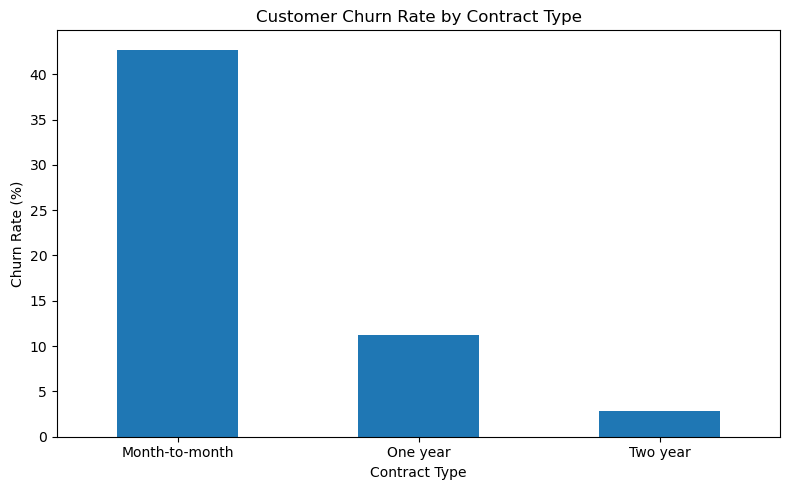

In [60]:
# customer churn rate by contract type 

import matplotlib.pyplot as plt

contract_rates = (
    df_analysis.groupby("Contract")["Churn Value"]
    .mean()
    .mul(100)
    .sort_values(ascending=False))

plt.figure(figsize=(8, 5))
contract_rates.plot(kind="bar")

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

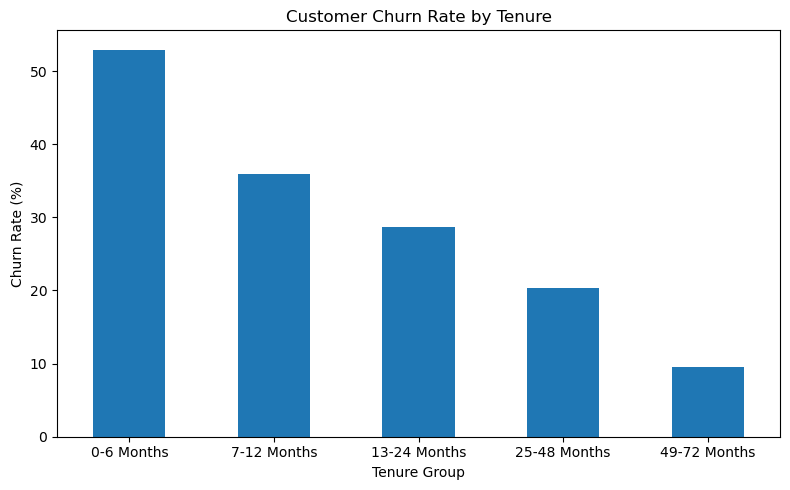

In [61]:
# customer churn rate by tenure

tenure_rates = (
    df_analysis.groupby("Tenure Group", observed=False)["Churn Value"]
    .mean()
    .mul(100))

plt.figure(figsize=(8, 5))
tenure_rates.plot(kind="bar")

plt.title("Customer Churn Rate by Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

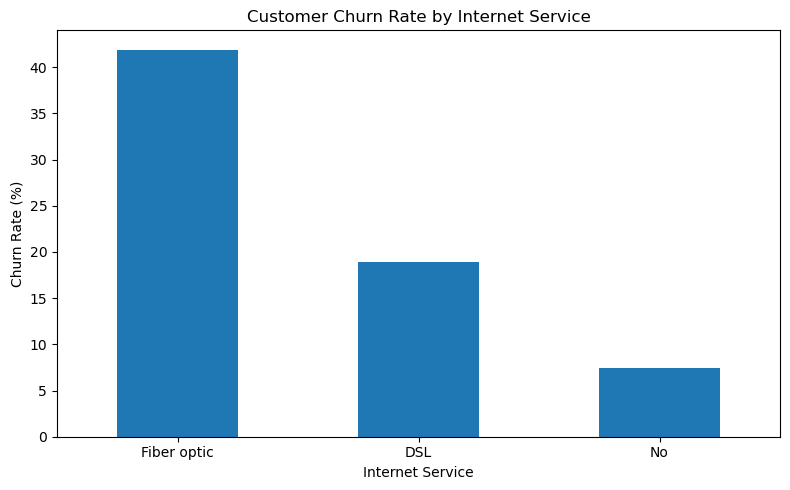

In [62]:
# churn by internet service 

internet_rates = (
    df_analysis.groupby("Internet Service")["Churn Value"]
    .mean()
    .mul(100)
    .sort_values(ascending=False))

plt.figure(figsize=(8, 5))
internet_rates.plot(kind="bar")

plt.title("Customer Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Highest-risk customer segment analysis

In [63]:
risk_segments = df_analysis.groupby(
    ["Contract", "Internet Service", "Tenure Group"], observed=True).agg(
    Customers=("Churn Value", "count"),
    Churned=("Churn Value", "sum"),
    Churn_Rate=("Churn Value", "mean"))

risk_segments["Churn_Rate"] = risk_segments["Churn_Rate"] * 100

risk_segments = risk_segments.sort_values(
    "Churn_Rate", ascending=False)

risk_segments.head(10)

Customers  Churned  Churn_Rate
Contract       Internet Service Tenure Group                                
One year       Fiber optic      0-6 Months            1        1  100.000000
Month-to-month Fiber optic      0-6 Months          619      459   74.151858
                                7-12 Months         297      184   61.952862
                                13-24 Months        425      215   50.588235
               No               49-72 Months          2        1   50.000000
               DSL              0-6 Months          495      245   49.494949
               Fiber optic      25-48 Months        521      226   43.378119
                                49-72 Months        266       78   29.323308
               No               0-6 Months          299       76   25.418060
               DSL              7-12 Months         195       48   24.615385

In [64]:
# Getting rid of tiny customer segments 
meaningful_segments = risk_segments[
    risk_segments["Customers"] >= 100
].sort_values("Churn_Rate", ascending=False)

meaningful_segments.head(10)

Customers  Churned  Churn_Rate
Contract       Internet Service Tenure Group                                
Month-to-month Fiber optic      0-6 Months          619      459   74.151858
                                7-12 Months         297      184   61.952862
                                13-24 Months        425      215   50.588235
               DSL              0-6 Months          495      245   49.494949
               Fiber optic      25-48 Months        521      226   43.378119
                                49-72 Months        266       78   29.323308
               No               0-6 Months          299       76   25.418060
               DSL              7-12 Months         195       48   24.615385
                                13-24 Months        232       55   23.706897
One year       Fiber optic      25-48 Months        154       31   20.129870

In [65]:
# month-to-month customers with fiber optic service have the highest churn rate 

In [68]:
# creating a csv containing the cleaned dataset

df_analysis.to_csv("telco_churn_cleansed.csv", index=False)
print("File exported successfully!")

File exported successfully!


In [70]:
import os

file_path = os.path.abspath("telco_churn_cleaned.csv")
print(repr(file_path))

'/Users/siyaparmar/Desktop/Customer Churn Project /telco_churn_cleaned.csv'
